In [ ]:
import torch 
# from tensordict import TensorDict 
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import plotly.graph_objects as go
%matplotlib inline


In [ ]:
def generate_height_scan_mirror(start_idx=140, rows=17, cols=11):
    mirror_indices = []
    for row in range(rows):
        for col in range(cols):
            mirror_col = cols - 1 - col
            mirror_idx = start_idx + row * cols + mirror_col
            mirror_indices.append(mirror_idx)
    mirror_signs = [1] * (rows * cols)
    return mirror_indices, mirror_signs

def generate_joint_mirror(start_idx):
    mirror_indices = []
    mirror_indices.extend([start_idx + 1, start_idx])    
    mirror_indices.append(start_idx + 2)
    for i in range(start_idx + 3, start_idx + 23, 2):
        mirror_indices.extend([i + 1, i])
    mirror_signs = [-1, -1, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, -1, -1, -1, -1]
    return mirror_indices, mirror_signs

def get_flip_indices_numpy(L, W, C):
    """
    获取图像水平翻转的索引数组 (NumPy 实现)
    
    参数:
        L: 图像高度
        W: 图像宽度
        C: 通道数
        
    返回:
        索引数组，形状为 [L, W, C]
    """
    # 创建行索引 (0 到 L-1)
    row_idx = np.arange(L).reshape(L, 1, 1)
    
    # 创建列索引 (从右到左: W-1 到 0)
    col_idx = np.arange(W-1, -1, -1).reshape(1, W, 1)
    
    # 创建通道索引 (0 到 C-1)
    ch_idx = np.arange(C).reshape(1, 1, C)
    
    # 使用广播机制组合索引
    indices = np.broadcast_to(row_idx, (L, W, C)).copy()
    indices[:, :, :] = np.broadcast_to(col_idx, (L, W, C))
    
    return indices

In [5]:
lab1_scan = np.array([[ 3.4163e-01,  8.7937e-01,  9.0000e-01],
        [ 2.6152e-01,  8.1952e-01,  9.0000e-01],
        [ 1.8141e-01,  7.5966e-01,  9.0000e-01],
        [ 1.0130e-01,  6.9981e-01,  9.0000e-01],
        [ 2.1187e-02,  6.3996e-01,  9.0000e-01],
        [-5.8924e-02,  5.8011e-01,  9.0000e-01],
        [-1.3904e-01,  5.2026e-01,  9.0000e-01],
        [-2.1915e-01,  4.6041e-01,  9.0000e-01],
        [-2.9926e-01,  4.0056e-01,  9.0000e-01],
        [-3.7937e-01,  3.4070e-01,  9.0000e-01],
        [-4.5948e-01,  2.8085e-01,  9.0000e-01],
        [-5.3959e-01,  2.2100e-01,  9.0000e-01],
        [-6.1970e-01,  1.6115e-01,  9.0000e-01],
        [-6.9981e-01,  1.0130e-01,  9.0000e-01],
        [-7.7992e-01,  4.1447e-02,  9.0000e-01],
        [-8.6004e-01, -1.8404e-02,  9.0000e-01],
        [-9.4015e-01, -7.8257e-02,  9.0000e-01],
        [ 4.0148e-01,  7.9926e-01,  9.0000e-01],
        [ 3.2137e-01,  7.3940e-01,  9.0000e-01],
        [ 2.4126e-01,  6.7955e-01,  9.0000e-01],
        [ 1.6115e-01,  6.1970e-01,  9.0000e-01],
        [ 8.1038e-02,  5.5985e-01,  9.0000e-01],
        [ 9.2745e-04,  5.0000e-01,  9.0000e-01],
        [-7.9184e-02,  4.4015e-01,  9.0000e-01],
        [-1.5930e-01,  3.8030e-01,  9.0000e-01],
        [-2.3941e-01,  3.2044e-01,  9.0000e-01],
        [-3.1952e-01,  2.6059e-01,  9.0000e-01],
        [-3.9963e-01,  2.0074e-01,  9.0000e-01],
        [-4.7974e-01,  1.4089e-01,  9.0000e-01],
        [-5.5985e-01,  8.1039e-02,  9.0000e-01],
        [-6.3996e-01,  2.1187e-02,  9.0000e-01],
        [-7.2007e-01, -3.8664e-02,  9.0000e-01],
        [-8.0018e-01, -9.8516e-02,  9.0000e-01],
        [-8.8030e-01, -1.5837e-01,  9.0000e-01],
        [ 4.6133e-01,  7.1914e-01,  9.0000e-01],
        [ 3.8122e-01,  6.5929e-01,  9.0000e-01],
        [ 3.0111e-01,  5.9944e-01,  9.0000e-01],
        [ 2.2100e-01,  5.3959e-01,  9.0000e-01],
        [ 1.4089e-01,  4.7974e-01,  9.0000e-01],
        [ 6.0779e-02,  4.1989e-01,  9.0000e-01],
        [-1.9332e-02,  3.6004e-01,  9.0000e-01],
        [-9.9443e-02,  3.0018e-01,  9.0000e-01],
        [-1.7955e-01,  2.4033e-01,  9.0000e-01],
        [-2.5967e-01,  1.8048e-01,  9.0000e-01],
        [-3.3978e-01,  1.2063e-01,  9.0000e-01],
        [-4.1989e-01,  6.0780e-02,  9.0000e-01],
        [-5.0000e-01,  9.2697e-04,  9.0000e-01],
        [-5.8011e-01, -5.8924e-02,  9.0000e-01],
        [-6.6022e-01, -1.1878e-01,  9.0000e-01],
        [-7.4033e-01, -1.7863e-01,  9.0000e-01],
        [-8.2044e-01, -2.3848e-01,  9.0000e-01],
        [ 5.2119e-01,  6.3903e-01,  9.0000e-01],
        [ 4.4107e-01,  5.7918e-01,  9.0000e-01],
        [ 3.6096e-01,  5.1933e-01,  9.0000e-01],
        [ 2.8085e-01,  4.5948e-01,  9.0000e-01],
        [ 2.0074e-01,  3.9963e-01,  9.0000e-01],
        [ 1.2063e-01,  3.3978e-01,  9.0000e-01],
        [ 4.0519e-02,  2.7992e-01,  9.0000e-01],
        [-3.9592e-02,  2.2007e-01,  9.0000e-01],
        [-1.1970e-01,  1.6022e-01,  9.0000e-01],
        [-1.9981e-01,  1.0037e-01,  9.0000e-01],
        [-2.7993e-01,  4.0520e-02,  9.0000e-01],
        [-3.6004e-01, -1.9333e-02,  9.0000e-01],
        [-4.4015e-01, -7.9184e-02,  9.0000e-01],
        [-5.2026e-01, -1.3904e-01,  9.0000e-01],
        [-6.0037e-01, -1.9889e-01,  9.0000e-01],
        [-6.8048e-01, -2.5874e-01,  9.0000e-01],
        [-7.6059e-01, -3.1859e-01,  9.0000e-01],
        [ 5.8104e-01,  5.5892e-01,  9.0000e-01],
        [ 5.0093e-01,  4.9907e-01,  9.0000e-01],
        [ 4.2082e-01,  4.3922e-01,  9.0000e-01],
        [ 3.4070e-01,  3.7937e-01,  9.0000e-01],
        [ 2.6059e-01,  3.1952e-01,  9.0000e-01],
        [ 1.8048e-01,  2.5967e-01,  9.0000e-01],
        [ 1.0037e-01,  1.9981e-01,  9.0000e-01],
        [ 2.0260e-02,  1.3996e-01,  9.0000e-01],
        [-5.9852e-02,  8.0111e-02,  9.0000e-01],
        [-1.3996e-01,  2.0260e-02,  9.0000e-01],
        [-2.2007e-01, -3.9593e-02,  9.0000e-01],
        [-3.0018e-01, -9.9443e-02,  9.0000e-01],
        [-3.8030e-01, -1.5929e-01,  9.0000e-01],
        [-4.6041e-01, -2.1915e-01,  9.0000e-01],
        [-5.4052e-01, -2.7900e-01,  9.0000e-01],
        [-6.2063e-01, -3.3885e-01,  9.0000e-01],
        [-7.0074e-01, -3.9870e-01,  9.0000e-01],
        [ 6.4089e-01,  4.7881e-01,  9.0000e-01],
        [ 5.6078e-01,  4.1896e-01,  9.0000e-01],
        [ 4.8067e-01,  3.5911e-01,  9.0000e-01],
        [ 4.0056e-01,  2.9926e-01,  9.0000e-01],
        [ 3.2044e-01,  2.3941e-01,  9.0000e-01],
        [ 2.4033e-01,  1.7955e-01,  9.0000e-01],
        [ 1.6022e-01,  1.1970e-01,  9.0000e-01],
        [ 8.0111e-02,  5.9851e-02,  9.0000e-01],
        [ 0.0000e+00,  0.0000e+00,  9.0000e-01],
        [-8.0111e-02, -5.9851e-02,  9.0000e-01],
        [-1.6022e-01, -1.1970e-01,  9.0000e-01],
        [-2.4033e-01, -1.7955e-01,  9.0000e-01],
        [-3.2044e-01, -2.3941e-01,  9.0000e-01],
        [-4.0056e-01, -2.9926e-01,  9.0000e-01],
        [-4.8067e-01, -3.5911e-01,  9.0000e-01],
        [-5.6078e-01, -4.1896e-01,  9.0000e-01],
        [-6.4089e-01, -4.7881e-01,  9.0000e-01],
        [ 7.0074e-01,  3.9870e-01,  9.0000e-01],
        [ 6.2063e-01,  3.3885e-01,  9.0000e-01],
        [ 5.4052e-01,  2.7900e-01,  9.0000e-01],
        [ 4.6041e-01,  2.1915e-01,  9.0000e-01],
        [ 3.8030e-01,  1.5929e-01,  9.0000e-01],
        [ 3.0018e-01,  9.9443e-02,  9.0000e-01],
        [ 2.2007e-01,  3.9593e-02,  9.0000e-01],
        [ 1.3996e-01, -2.0260e-02,  9.0000e-01],
        [ 5.9852e-02, -8.0111e-02,  9.0000e-01],
        [-2.0260e-02, -1.3996e-01,  9.0000e-01],
        [-1.0037e-01, -1.9981e-01,  9.0000e-01],
        [-1.8048e-01, -2.5967e-01,  9.0000e-01],
        [-2.6059e-01, -3.1952e-01,  9.0000e-01],
        [-3.4070e-01, -3.7937e-01,  9.0000e-01],
        [-4.2082e-01, -4.3922e-01,  9.0000e-01],
        [-5.0093e-01, -4.9907e-01,  9.0000e-01],
        [-5.8104e-01, -5.5892e-01,  9.0000e-01],
        [ 7.6059e-01,  3.1859e-01,  9.0000e-01],
        [ 6.8048e-01,  2.5874e-01,  9.0000e-01],
        [ 6.0037e-01,  1.9889e-01,  9.0000e-01],
        [ 5.2026e-01,  1.3904e-01,  9.0000e-01],
        [ 4.4015e-01,  7.9184e-02,  9.0000e-01],
        [ 3.6004e-01,  1.9333e-02,  9.0000e-01],
        [ 2.7993e-01, -4.0520e-02,  9.0000e-01],
        [ 1.9981e-01, -1.0037e-01,  9.0000e-01],
        [ 1.1970e-01, -1.6022e-01,  9.0000e-01],
        [ 3.9592e-02, -2.2007e-01,  9.0000e-01],
        [-4.0519e-02, -2.7992e-01,  9.0000e-01],
        [-1.2063e-01, -3.3978e-01,  9.0000e-01],
        [-2.0074e-01, -3.9963e-01,  9.0000e-01],
        [-2.8085e-01, -4.5948e-01,  9.0000e-01],
        [-3.6096e-01, -5.1933e-01,  9.0000e-01],
        [-4.4107e-01, -5.7918e-01,  9.0000e-01],
        [-5.2119e-01, -6.3903e-01,  9.0000e-01],
        [ 8.2044e-01,  2.3848e-01,  9.0000e-01],
        [ 7.4033e-01,  1.7863e-01,  9.0000e-01],
        [ 6.6022e-01,  1.1878e-01,  9.0000e-01],
        [ 5.8011e-01,  5.8924e-02,  9.0000e-01],
        [ 5.0000e-01, -9.2697e-04,  9.0000e-01],
        [ 4.1989e-01, -6.0780e-02,  9.0000e-01],
        [ 3.3978e-01, -1.2063e-01,  9.0000e-01],
        [ 2.5967e-01, -1.8048e-01,  9.0000e-01],
        [ 1.7955e-01, -2.4033e-01,  9.0000e-01],
        [ 9.9443e-02, -3.0019e-01,  9.0000e-01],
        [ 1.9332e-02, -3.6004e-01,  9.0000e-01],
        [-6.0779e-02, -4.1989e-01,  9.0000e-01],
        [-1.4089e-01, -4.7974e-01,  9.0000e-01],
        [-2.2100e-01, -5.3959e-01,  9.0000e-01],
        [-3.0111e-01, -5.9944e-01,  9.0000e-01],
        [-3.8122e-01, -6.5929e-01,  9.0000e-01],
        [-4.6133e-01, -7.1915e-01,  9.0000e-01],
        [ 8.8030e-01,  1.5837e-01,  9.5496e-01],
        [ 8.0018e-01,  9.8516e-02,  9.0000e-01],
        [ 7.2007e-01,  3.8664e-02,  9.0000e-01],
        [ 6.3996e-01, -2.1187e-02,  9.0000e-01],
        [ 5.5985e-01, -8.1039e-02,  9.0000e-01],
        [ 4.7974e-01, -1.4089e-01,  9.0000e-01],
        [ 3.9963e-01, -2.0074e-01,  9.0000e-01],
        [ 3.1952e-01, -2.6059e-01,  9.0000e-01],
        [ 2.3941e-01, -3.2044e-01,  9.0000e-01],
        [ 1.5930e-01, -3.8030e-01,  9.0000e-01],
        [ 7.9184e-02, -4.4015e-01,  9.0000e-01],
        [-9.2745e-04, -5.0000e-01,  9.0000e-01],
        [-8.1038e-02, -5.5985e-01,  9.0000e-01],
        [-1.6115e-01, -6.1970e-01,  9.0000e-01],
        [-2.4126e-01, -6.7955e-01,  9.0000e-01],
        [-3.2137e-01, -7.3940e-01,  9.0000e-01],
        [-4.0148e-01, -7.9926e-01,  9.0000e-01],
        [ 9.4015e-01,  7.8257e-02,  9.5496e-01],
        [ 8.6004e-01,  1.8404e-02,  9.5496e-01],
        [ 7.7992e-01, -4.1447e-02,  9.0000e-01],
        [ 6.9981e-01, -1.0130e-01,  9.0000e-01],
        [ 6.1970e-01, -1.6115e-01,  9.0000e-01],
        [ 5.3959e-01, -2.2100e-01,  9.0000e-01],
        [ 4.5948e-01, -2.8085e-01,  9.0000e-01],
        [ 3.7937e-01, -3.4070e-01,  9.0000e-01],
        [ 2.9926e-01, -4.0056e-01,  9.0000e-01],
        [ 2.1915e-01, -4.6041e-01,  9.0000e-01],
        [ 1.3904e-01, -5.2026e-01,  9.0000e-01],
        [ 5.8924e-02, -5.8011e-01,  9.0000e-01],
        [-2.1187e-02, -6.3996e-01,  9.0000e-01],
        [-1.0130e-01, -6.9981e-01,  9.0000e-01],
        [-1.8141e-01, -7.5966e-01,  9.0000e-01],
        [-2.6152e-01, -8.1952e-01,  9.0000e-01],
        [-3.4163e-01, -8.7937e-01,  9.0000e-01]])

In [4]:
lab2_scan = np.array(
    [[ 0.6676,  0.6666,  0.8923],
         [ 0.5701,  0.6442,  0.8923],
         [ 0.4727,  0.6218,  0.8923],
         [ 0.3752,  0.5994,  0.8923],
         [ 0.2777,  0.5769,  0.8923],
         [ 0.1803,  0.5545,  0.8923],
         [ 0.0828,  0.5321,  0.8923],
         [-0.0146,  0.5097,  0.8923],
         [-0.1121,  0.4873,  0.8923],
         [-0.2095,  0.4649,  0.8923],
         [-0.3070,  0.4424,  0.8923],
         [-0.4044,  0.4200,  0.8923],
         [-0.5019,  0.3976,  0.8923],
         [-0.5994,  0.3752,  0.8923],
         [-0.6968,  0.3528,  0.9472],
         [-0.7943,  0.3304,  0.9472],
         [-0.8917,  0.3080,  0.9472],
         [ 0.6900,  0.5691,  0.8923],
         [ 0.5925,  0.5467,  0.8923],
         [ 0.4951,  0.5243,  0.8923],
         [ 0.3976,  0.5019,  0.8923],
         [ 0.3002,  0.4795,  0.8923],
         [ 0.2027,  0.4571,  0.8923],
         [ 0.1052,  0.4347,  0.8923],
         [ 0.0078,  0.4122,  0.8923],
         [-0.0897,  0.3898,  0.8923],
         [-0.1871,  0.3674,  0.8923],
         [-0.2846,  0.3450,  0.8923],
         [-0.3820,  0.3226,  0.8923],
         [-0.4795,  0.3002,  0.8923],
         [-0.5769,  0.2777,  0.8923],
         [-0.6744,  0.2553,  0.9472],
         [-0.7718,  0.2329,  0.9472],
         [-0.8693,  0.2105,  0.9472],
         [ 0.7124,  0.4717,  0.8923],
         [ 0.6149,  0.4493,  0.8923],
         [ 0.5175,  0.4269,  0.8923],
         [ 0.4200,  0.4044,  0.8923],
         [ 0.3226,  0.3820,  0.8923],
         [ 0.2251,  0.3596,  0.8923],
         [ 0.1277,  0.3372,  0.8923],
         [ 0.0302,  0.3148,  0.8923],
         [-0.0672,  0.2924,  0.8923],
         [-0.1647,  0.2700,  0.8923],
         [-0.2622,  0.2475,  0.8923],
         [-0.3596,  0.2251,  0.8923],
         [-0.4571,  0.2027,  0.8923],
         [-0.5545,  0.1803,  0.8923],
         [-0.6520,  0.1579,  0.8923],
         [-0.7494,  0.1355,  0.9472],
         [-0.8469,  0.1130,  0.9472],
         [ 0.7348,  0.3742,  0.8923],
         [ 0.6374,  0.3518,  0.8923],
         [ 0.5399,  0.3294,  0.8923],
         [ 0.4424,  0.3070,  0.8923],
         [ 0.3450,  0.2846,  0.8923],
         [ 0.2475,  0.2622,  0.8923],
         [ 0.1501,  0.2397,  0.8923],
         [ 0.0526,  0.2173,  0.8923],
         [-0.0448,  0.1949,  0.8923],
         [-0.1423,  0.1725,  0.8923],
         [-0.2397,  0.1501,  0.8923],
         [-0.3372,  0.1277,  0.8923],
         [-0.4347,  0.1052,  0.8923],
         [-0.5321,  0.0828,  0.8923],
         [-0.6296,  0.0604,  0.8923],
         [-0.7270,  0.0380,  0.9472],
         [-0.8245,  0.0156,  0.9472],
         [ 0.7572,  0.2768,  0.8923],
         [ 0.6598,  0.2544,  0.8923],
         [ 0.5623,  0.2319,  0.8923],
         [ 0.4649,  0.2095,  0.8923],
         [ 0.3674,  0.1871,  0.8923],
         [ 0.2700,  0.1647,  0.8923],
         [ 0.1725,  0.1423,  0.8923],
         [ 0.0750,  0.1199,  0.8923],
         [-0.0224,  0.0975,  0.8923],
         [-0.1199,  0.0750,  0.8923],
         [-0.2173,  0.0526,  0.8923],
         [-0.3148,  0.0302,  0.8923],
         [-0.4122,  0.0078,  0.8923],
         [-0.5097, -0.0146,  0.8923],
         [-0.6071, -0.0370,  0.8923],
         [-0.7046, -0.0595,  0.9472],
         [-0.8021, -0.0819,  0.9472],
         [ 0.7796,  0.1793,  0.8923],
         [ 0.6822,  0.1569,  0.8923],
         [ 0.5847,  0.1345,  0.8923],
         [ 0.4873,  0.1121,  0.8923],
         [ 0.3898,  0.0897,  0.8923],
         [ 0.2924,  0.0672,  0.8923],
         [ 0.1949,  0.0448,  0.8923],
         [ 0.0975,  0.0224,  0.8923],
         [ 0.0000,  0.0000,  0.8923],
         [-0.0975, -0.0224,  0.8923],
         [-0.1949, -0.0448,  0.8923],
         [-0.2924, -0.0672,  0.8923],
         [-0.3898, -0.0897,  0.8923],
         [-0.4873, -0.1121,  0.8923],
         [-0.5847, -0.1345,  0.8923],
         [-0.6822, -0.1569,  0.9472],
         [-0.7796, -0.1793,  0.9472],
         [ 0.8021,  0.0819,  0.8923],
         [ 0.7046,  0.0595,  0.8923],
         [ 0.6071,  0.0370,  0.8923],
         [ 0.5097,  0.0146,  0.8923],
         [ 0.4122, -0.0078,  0.8923],
         [ 0.3148, -0.0302,  0.8923],
         [ 0.2173, -0.0526,  0.8923],
         [ 0.1199, -0.0750,  0.8923],
         [ 0.0224, -0.0975,  0.8923],
         [-0.0750, -0.1199,  0.8923],
         [-0.1725, -0.1423,  0.8923],
         [-0.2700, -0.1647,  0.8923],
         [-0.3674, -0.1871,  0.8923],
         [-0.4649, -0.2095,  0.8923],
         [-0.5623, -0.2319,  0.8923],
         [-0.6598, -0.2544,  0.8923],
         [-0.7572, -0.2768,  0.9472],
         [ 0.8245, -0.0156,  0.8923],
         [ 0.7270, -0.0380,  0.8923],
         [ 0.6296, -0.0604,  0.8923],
         [ 0.5321, -0.0828,  0.8923],
         [ 0.4347, -0.1052,  0.8923],
         [ 0.3372, -0.1277,  0.8923],
         [ 0.2397, -0.1501,  0.8923],
         [ 0.1423, -0.1725,  0.8923],
         [ 0.0448, -0.1949,  0.8923],
         [-0.0526, -0.2173,  0.8923],
         [-0.1501, -0.2397,  0.8923],
         [-0.2475, -0.2622,  0.8923],
         [-0.3450, -0.2846,  0.8923],
         [-0.4424, -0.3070,  0.8923],
         [-0.5399, -0.3294,  0.8923],
         [-0.6374, -0.3518,  0.8923],
         [-0.7348, -0.3742,  0.9472],
         [ 0.8469, -0.1130,  0.8923],
         [ 0.7494, -0.1355,  0.8923],
         [ 0.6520, -0.1579,  0.8923],
         [ 0.5545, -0.1803,  0.8923],
         [ 0.4571, -0.2027,  0.8923],
         [ 0.3596, -0.2251,  0.8923],
         [ 0.2622, -0.2475,  0.8923],
         [ 0.1647, -0.2700,  0.8923],
         [ 0.0672, -0.2924,  0.8923],
         [-0.0302, -0.3148,  0.8923],
         [-0.1277, -0.3372,  0.8923],
         [-0.2251, -0.3596,  0.8923],
         [-0.3226, -0.3820,  0.8923],
         [-0.4200, -0.4044,  0.8923],
         [-0.5175, -0.4269,  0.8923],
         [-0.6149, -0.4493,  0.8923],
         [-0.7124, -0.4717,  0.9472],
         [ 0.8693, -0.2105,  0.8923],
         [ 0.7718, -0.2329,  0.8923],
         [ 0.6744, -0.2553,  0.8923],
         [ 0.5769, -0.2777,  0.8923],
         [ 0.4795, -0.3002,  0.8923],
         [ 0.3820, -0.3226,  0.8923],
         [ 0.2846, -0.3450,  0.8923],
         [ 0.1871, -0.3674,  0.8923],
         [ 0.0897, -0.3898,  0.8923],
         [-0.0078, -0.4122,  0.8923],
         [-0.1052, -0.4347,  0.8923],
         [-0.2027, -0.4571,  0.8923],
         [-0.3002, -0.4795,  0.8923],
         [-0.3976, -0.5019,  0.8923],
         [-0.4951, -0.5243,  0.8923],
         [-0.5925, -0.5467,  0.8923],
         [-0.6900, -0.5691,  0.9472],
         [ 0.8917, -0.3080,  0.8923],
         [ 0.7943, -0.3304,  0.8923],
         [ 0.6968, -0.3528,  0.8923],
         [ 0.5994, -0.3752,  0.8923],
         [ 0.5019, -0.3976,  0.8923],
         [ 0.4044, -0.4200,  0.8923],
         [ 0.3070, -0.4424,  0.8923],
         [ 0.2095, -0.4649,  0.8923],
         [ 0.1121, -0.4873,  0.8923],
         [ 0.0146, -0.5097,  0.8923],
         [-0.0828, -0.5321,  0.8923],
         [-0.1803, -0.5545,  0.8923],
         [-0.2777, -0.5769,  0.8923],
         [-0.3752, -0.5994,  0.8923],
         [-0.4727, -0.6218,  0.8923],
         [-0.5701, -0.6442,  0.8923],
         [-0.6676, -0.6666,  0.9472]]
)

In [2]:
mujoco = np.loadtxt('mujoco_scan.txt',delimiter=',').reshape(11,17,3)

In [6]:
mamba = lab1_scan.reshape(11,17,3)

In [7]:
shi = lab2_scan.reshape(11,17,3)

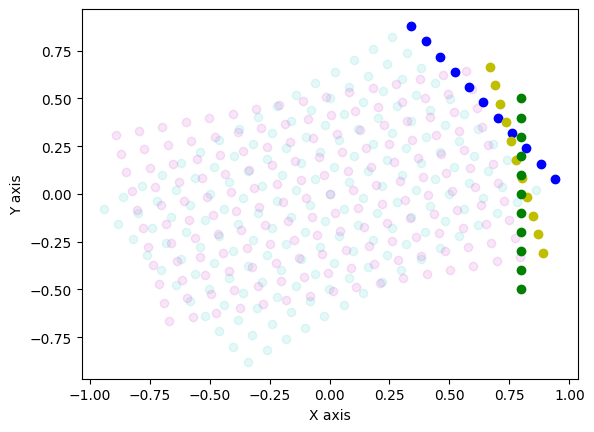

In [15]:
plt.scatter(mamba[:,:,0],mamba[:,:,1],c='c',alpha=0.1)
plt.scatter(shi[:,:,0],shi[:,:,1],c='m',alpha=0.1)
# plt.scatter(mamba[0,:,0],mamba[0,:,1],c='b')
# plt.scatter(shi[0,:,0],shi[0,:,1],c='y')
plt.scatter(mamba[:,0,0],mamba[:,0,1],c='b')
plt.scatter(shi[:,0,0],shi[:,0,1],c='y')
plt.scatter(mujoco[:,0,0],mujoco[:,0,1],c='g')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()

In [18]:
# 3D scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=mamba[:,:,0].flatten(), 
                           y=mamba[:,:,1].flatten(), 
                           z=mamba[:,:,2].flatten(), 
                           mode='markers',
                           marker=dict(
                            size=5,
                            color='cyan',
                            opacity=0.8),
                            name='isaaclab'))
fig.add_trace(go.Scatter3d(x=mujoco[:,:,0].flatten(), 
                           y=mujoco[:,:,1].flatten(), 
                           z=mujoco[:,:,2].flatten(), 
                           mode='markers',
                           marker=dict(
                               size=5,
                               color='yellow',
                               opacity=0.8),
                            name='mujoco'))
# 3) 统一布局
fig.update_layout(
    title='map_scan',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    width=600, height=500
)
fig.show()

In [16]:
height_scan = map_scan[0]
flip_indice = get_flip_indices_numpy(17,11,1)
flip_height_scan = height_scan[:,flip_indice[0,:,0],:]

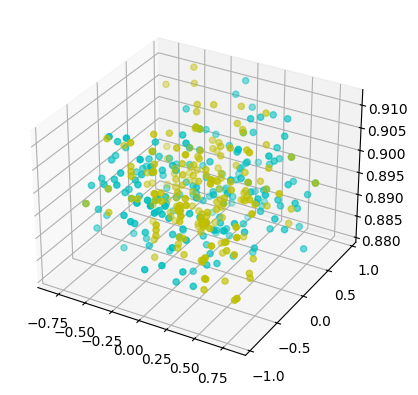

In [55]:
# 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(height_scan[:,:,0],height_scan[:,:,1],height_scan[:,:,2],c='c')
ax.scatter(height_scan[:,:,0],flip_height_scan[:,:,1],flip_height_scan[:,:,2],c='y')
plt.show()

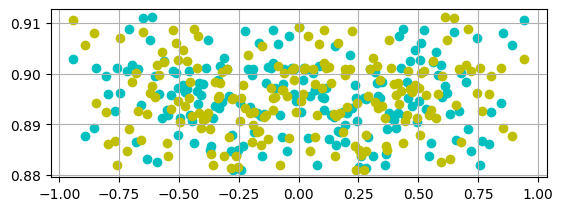

In [56]:
plt.subplot(2,1,1)
plt.scatter(height_scan[:,:,1],height_scan[:,:,2],c='c')
# plt.colorbar()
# plt.subplot(2,1,2)
plt.scatter(-flip_height_scan[:,:,1],flip_height_scan[:,:,2],c='y')
plt.grid()
plt.show()

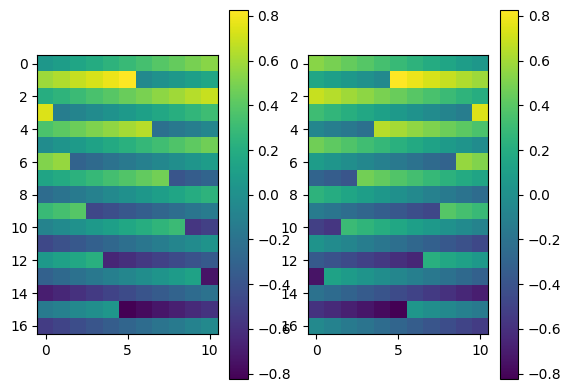

In [36]:
plt.subplot(1,2,1)
plt.imshow(height_scan[:,:,0])
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(flip_height_scan[:,:,0])
# plt.imshow(flip_map_scan_2d, cmap='gray')
plt.colorbar()
plt.show()

In [30]:
# for flatten 
flat_height_scan = height_scan[:,:,0].flatten()
# height_scan = np.arange(0,187,1)
# height_scan = np.array([(i%2)*np.arange(0,11,1) for i in range(17)]).flatten()
flat_flip_indices1 = [170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186,
                             153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
                             136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
                             119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
                             102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
                             85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101,
                             68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
                             51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
                             34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
                             17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
                             0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
flat_flip_indices2,_ = generate_height_scan_mirror(0)
flip_flat_scan1 = flat_height_scan[flat_flip_indices1]
flip_flat_scan2 = flat_height_scan[flat_flip_indices2]

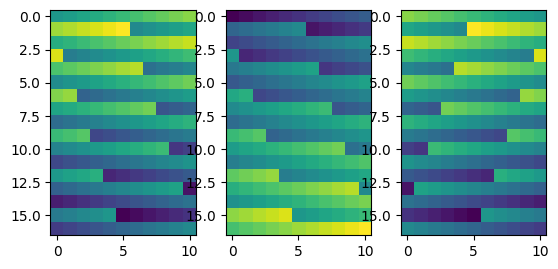

In [38]:
plt.subplot(1,3,1)
plt.imshow(height_scan[:,:,0])
# plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(flip_flat_scan1.reshape(17,11))
# plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(flip_flat_scan2.reshape(17,11))
# plt.colorbar()
plt.show()

height_scan[:,:,1]

In [63]:
class SymmetryAug2D:
    """
    symmetry augmentation for 2D Tensor, which shape is [B,H*d]
    """
    OBS_MIRROR_REGIST_KEYS = {}  # 注册的key
    OBS_MIRROR_INDICES_DICT = {}  # 注册的key对应的镜像索引    
    OBS_MIRROR_SIGNS_DICT = {}  # 注册的key对应的
    # for lab sytle joint indices for kuavo s42
    ACT_MIRROR_INDICES = [1, 0, 3, 2, 5, 4, 7, 6, 9, 8, 11, 10, 13, 12, 15, 14, 17, 16, 19, 18, 21, 20, 23, 22, 25, 24]
    ACT_MIRROR_SIGNS = [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]
    # supprot keys 
    OBS_MIRROR_SUPPORT_DICT = {
            "base_ang_vel":[[0, 1, 2],[-1,1,-1]],
            "gravity":[[0,1,2],[1,-1,1]],
            "cmd":[[0,1,2,3],[1, -1, -1, 1]],
            "cmd_vel":[[0,1,2],[1, -1, -1]],
            "hugwbc_cmd":[[0],[1]],
            "joint_pos":[[1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10,
                            13, 12, 15, 14, 17,16, 19, 18, 21, 20, 23, 22, 25, 24],
                        [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]],
            "joint_vel":[[1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10,
                            13, 12, 15, 14, 17,16, 19, 18, 21, 20, 23, 22, 25, 24],
                        [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]],
            "action":[[1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10,
                            13, 12, 15, 14, 17,16, 19, 18, 21, 20, 23, 22, 25, 24],
                        [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]],
            "base_lin_vel": [[0, 1, 2],[1, -1, 1]],
            # 高程图，1.6m x 1.0m，分辨率0.1m，共17x11个点，排列顺序为xy，所以关于y对称就是每隔17个点为一列，把这11列倒序排列即可。符号不变。
            "height_scan": generate_height_scan_mirror(0,17,11),
            "joint_torques": [[1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10,
                            13, 12, 15, 14, 17,16, 19, 18, 21, 20, 23, 22, 25, 24],
                        [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]],
            "joint_accs": [[1,  0,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10,
                            13, 12, 15, 14, 17,16, 19, 18, 21, 20, 23, 22, 25, 24],
                        [-1, -1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1]],
            "feet_lin_vel": [[3, 4, 5, 0, 1, 2],[1, -1, 1, 1, -1, 1]],
            "feet_contact_force": [[3, 4, 5, 0, 1, 2],[1, -1, 1, 1, -1, 1]],
            "base_mass_rel": [[0,],[1,]],
            "rigid_body_material": [[3, 4, 5, 0, 1, 2],[1, 1, 1, 1, 1, 1]],
            "base_com": [[0,1,2],[1,-1,1]],
            "action_delay": [[0,],[1,]],
            "push_force": [[0,1,2],[1,-1,1]],
            "push_torque": [[0, 1, 2],[-1,1,-1]],
            "feet_heights": [[1,0],[1,1]],
            "feet_air_times": [[1,0],[1,1]],
    }
    
    @staticmethod
    def mirror_tensors(tensor, mirror_indices, mirror_signs):
        mirrored_tensor = tensor[..., mirror_indices]
        mirror_signs_tensor = torch.tensor(mirror_signs, dtype=tensor.dtype, device=tensor.device)
        mirrored_tensor = mirrored_tensor * mirror_signs_tensor
        return mirrored_tensor
    
    @classmethod
    def clear(cls):
        cls.OBS_MIRROR_REGIST_KEYS = {}
        cls.OBS_MIRROR_INDICES_DICT = {}
        cls.OBS_MIRROR_SIGNS_DICT = {}

    @classmethod
    def register_obs(cls, key:str, obsgroup:list,history_len:int=1):
        # step 1 : check is supported
        # assert key in cls.OBS_MIRROR_SUPPORT_DICT.keys(), f"key {key} is not supported"
        # step 2 : register
        if key not in cls.OBS_MIRROR_REGIST_KEYS.keys():
            cls.OBS_MIRROR_REGIST_KEYS[key] = obsgroup
        else:
            for obsterm in obsgroup:
                assert obsterm not in cls.OBS_MIRROR_REGIST_KEYS[key], f"Obsterm {obsterm} is already registered"
            cls.OBS_MIRROR_REGIST_KEYS[key].extend(obsgroup)
        # step 3 : generate mirror indices and signs 
        idx = 0
        obs_mirror_indices = []
        obs_mirror_signs = []
        for obsterm in cls.OBS_MIRROR_REGIST_KEYS[key]:
            n = len(cls.OBS_MIRROR_SUPPORT_DICT[obsterm][0])
            for i in range(history_len):
                start_idx = idx 
                obs_mirror_indices.extend([i + start_idx for i in cls.OBS_MIRROR_SUPPORT_DICT[obsterm][0]])
                obs_mirror_signs.extend(cls.OBS_MIRROR_SUPPORT_DICT[obsterm][1])
                idx += n
        cls.OBS_MIRROR_INDICES_DICT[key] = obs_mirror_indices
        cls.OBS_MIRROR_SIGNS_DICT[key] = obs_mirror_signs

    @classmethod
    def register_policy_obs(cls,obsgroup:list,history_len=1):        
        """
        :brief : this method is used for register obs group for policy, used for rsl rl <= 3.0.1 version
        """
        k = 'policy'
        cls.register_obs(k,obsgroup,history_len)
    
    @classmethod
    def register_critic_obs(cls,obsgroup:list,history_len=1):        
        """
        :brief : this method is used for register obs group for critic, used for rsl rl <= 3.0.1 version
        """
        k = 'critic'
        cls.register_obs(k,obsgroup,history_len)
    
    @classmethod
    def data_augmentation_tensor(cls,env,obs:torch.Tensor,actions:torch.Tensor,obs_type:str)->tuple:
        """
        :brief : this method is used for data augmentation with rsl rl version <= 3.0.1, which VecEnv.get_observation() 
        returns (torch.Tensor, dict) instead of TensorDict.
        """
        if obs is None:
            obs_aug = None
        else:
            if obs_type == 'policy':
                policy_mirror_indices = cls.OBS_MIRROR_INDICES_DICT['policy']
                policy_mirror_signs = cls.OBS_MIRROR_SIGNS_DICT['policy']
                obs_aug = torch.cat((obs, cls.mirror_tensors(obs, policy_mirror_indices, policy_mirror_signs)), dim=0)
            elif obs_type == 'critic':
                critic_mirror_indices = cls.OBS_MIRROR_INDICES_DICT['critic']
                critic_mirror_signs = cls.OBS_MIRROR_SIGNS_DICT['critic']
                obs_aug = torch.cat((obs, cls.mirror_tensors(obs, critic_mirror_indices, critic_mirror_signs)), dim=0)
            else:
                raise ValueError(f"Mirror logic for observation type '{obs_type}' not implemented")
        if actions is None:
            actions_aug = None
        else:
            actions_aug = torch.cat((actions, cls.mirror_tensors(actions, cls.ACT_MIRROR_INDICES, cls.ACT_MIRROR_SIGNS)), dim=0)
        return obs_aug, actions_aug

    @classmethod
    def data_augmentation_dict(cls,env, obs:TensorDict, actions:torch.Tensor)->tuple:
        """
        :brief : this method is used for data augmentation with rsl rl version > 3.0.1, which VecEnv.get_observation() 
        returns a TensorDict
        """
        if obs is None:
            obs_aug = None 
        else:
            obs_aug = TensorDict()
            for k in obs.keys():
                assert k in cls.OBS_MIRROR_REGIST_KEYS.keys(), f"Observation key '{k}' not in mirror regist keys"
                mirror_indices = cls.OBS_MIRROR_INDICES_DICT[k]
                mirror_signs = cls.OBS_MIRROR_SIGNS_DICT[k]
                obs_k_aug = torch.cat((obs, cls.mirror_tensors(obs[k], 
                    mirror_indices, mirror_signs)), dim=0)
                obs_aug[k] = obs_k_aug
        if actions is None:
            actions_aug = None
        else:
            actions_aug = torch.cat((actions, cls.mirror_tensors(actions, cls.ACT_MIRROR_INDICES, cls.ACT_MIRROR_SIGNS)), dim=0)
        return obs_aug, actions_aug

In [66]:
getattr(SymmetryAug2D,"data_augmentation_dict")

<bound method SymmetryAug2D.data_augmentation_dict of <class '__main__.SymmetryAug2D'>>

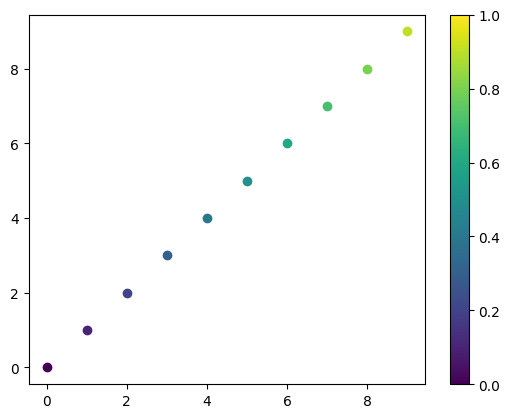

In [15]:
for i in range(10):
    plt.scatter(i,i, color=mpl.colormaps['viridis'](i/10))
plt.colorbar()
plt.show()


In [ ]:
[i for i in range(27)]